In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyMelt import phaseDiagramTools

In [5]:
results = pd.read_csv('../phaseDiagrams/klb1_holland2018/table_klb1_holland2018.csv')
results.head()

,P,T,spn_wtpt_O,spn,spn_wtpt_FeO,opx,heat_capacity,cpx_cbuf,ol_wtpt_H2O,cpx_cfs,...,g_tig,g_gr,g_alm,g,g_wtpt_H2O,g_wtpt_FeO,g_wtpt_O,g_wtpt_SiO2,g_wtpt_Na2O,g_knom
0,0.01,1100.000000,0.880645,0.000838,21.232484,0.179617,0.214807,0.024430,0.0,0.057052,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.01,1105.025126,0.871742,0.000807,21.123468,0.179789,0.215532,0.024864,0.0,0.057187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.01,1110.050251,0.862899,0.000776,21.024771,0.179960,0.215749,0.025307,0.0,0.057360,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.01,1115.075377,0.854287,0.000745,20.920343,0.180127,0.215282,0.025759,0.0,0.057503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.01,1120.100503,0.845819,0.000713,20.818217,0.180291,0.215793,0.026221,0.0,0.057650,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Format the data table

Replace thermocalc phase nomenclature with pyMelt nomenclature:

In [6]:
for col in results.columns:
    if col.split('_')[0] == 'ol':
        # print('olv'+col[2:])
        results['olv'+col[2:]] = results[col]
        results.drop(col, axis=1, inplace=True)
    elif col.split('_')[0] == 'g':
        results['grt'+col[1:]] = results[col]
        results.drop(col, axis=1, inplace=True)
    elif col.split('_')[0] == 'fsp':
        results['plg'+col[3:]] = results[col]
        results.drop(col, axis=1, inplace=True)

Remove H2O (which should all be 0):

In [7]:
for col in results.columns:
    if col.split('_')[-1] == 'H2O':
        results.drop(col, axis=1, inplace=True)

Replace O with Fe2O3:

In [8]:
for col in results.columns:
    cs = col.split('_')
    if cs[-1] == 'O':
        results[cs[0] + '_wtpt_FeO'] = (results[cs[0] + '_wtpt_FeO'] / 71.844 - results[cs[0] + '_wtpt_O'] / 15.999 * 2) * 71.844
        results[cs[0] + '_wtpt_Fe2O3'] = results[cs[0] + '_wtpt_O'] / 15.999 * 159.69
        results.drop(col, axis=1, inplace=True)


Relabel temperature and pressure:

In [9]:
results['temperature'] = results['T']
results.drop('T', axis=1, inplace=True)
results['pressure'] = results['P']
results.drop('P', axis=1, inplace=True)

Reorder wtpt labels:

In [10]:
for col in results.columns:
    cs = col.split('_')
    if len(cs) > 1 and cs[1] == 'wtpt':
        results[cs[0] + '_' + cs[2] + '_wtpt'] = results[col]
        results.drop(col, axis=1, inplace=True)

In [11]:
for col in results.columns:
    if col in ['olv', 'cpx', 'opx', 'grt', 'spn', 'plg', 'liq']:
        results[col + '_mass'] = results[col]
        results.drop(col, axis=1, inplace=True)

In [13]:
grid = phaseDiagramTools.gridsMAGEMin(results)

In [32]:
S = grid.make_f_grid('entropy')
Cp = grid.make_f_grid('heat_capacity')
T = grid.make_f_grid('temperature')

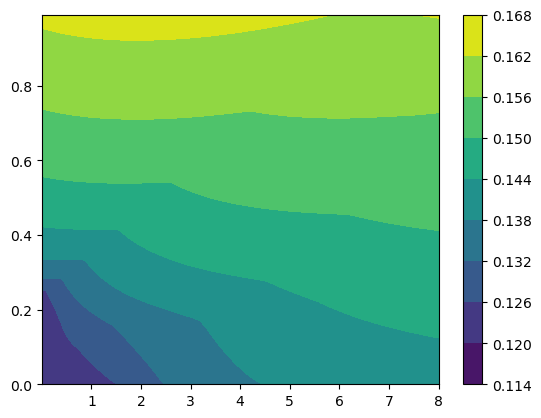

In [24]:
f, a = plt.subplots()

cf = a.contourf(S[0], S[1], S[2])

plt.colorbar(cf)

plt.show()

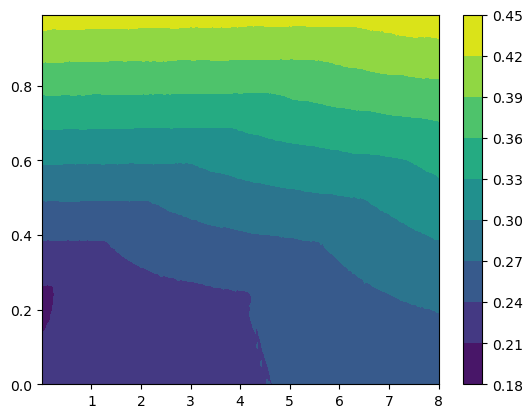

In [25]:
f, a = plt.subplots()

cf = a.contourf(Cp[0], Cp[1], Cp[2])

plt.colorbar(cf)

plt.show()

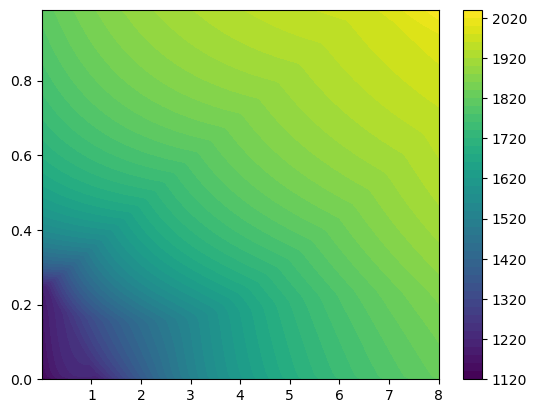

In [67]:
f, a = plt.subplots()

cf = a.contourf(T[0], T[1], T[2], levels=50)

plt.colorbar(cf)

plt.show()

In [27]:
S[1]

array([[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.02, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
       ...,
       [0.97, 0.97, 0.97, ..., 0.97, 0.97, 0.97],
       [0.98, 0.98, 0.98, ..., 0.98, 0.98, 0.98],
       [0.99, 0.99, 0.99, ..., 0.99, 0.99, 0.99]])

In [64]:
S = grid.make_f_grid('entropy')
Cp = grid.make_f_grid('heat_capacity')
T = grid.make_f_grid('temperature')
DeltaSm = np.zeros([np.shape(S)[1], np.shape(S)[2]])
F = S[1]
T = T[2]
S = S[2]
Cp = Cp[2]

for j in range(np.shape(DeltaSm)[1]):
    for i in range(np.shape(DeltaSm)[0]-1):
        DeltaSm[i,j] = ((S[i+1,j] - S[i, j]) - Cp[i,j] / (T[i,j]+273.15) * (T[i+1, j] - T[i,j])) / (F[i+1,j] - F[i,j])


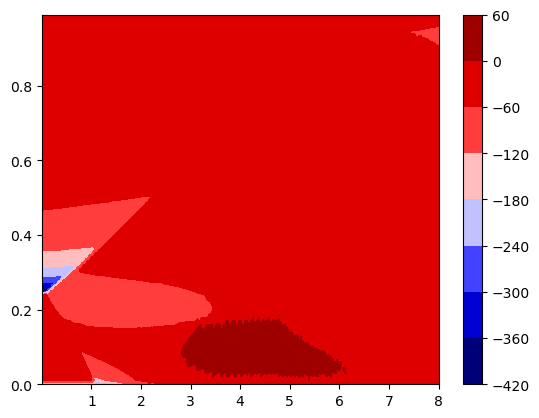

In [65]:
f, a = plt.subplots()
T = grid.make_f_grid('temperature')

cf = a.contourf(T[0], T[1], DeltaSm*1000, cmap=plt.cm.seismic)#, levels=np.linspace(-420,420,100))

plt.colorbar(cf)

plt.show()